# baseline

將`關鍵字`比對換成`向量相似度`比對。

> 請將目前使用關鍵字比對的 route_by_query，改為使用向量相似度進行分類，並設一個合理的相似度門檻，根據檢索結果的分數判斷是否走 RAG 流程。  
例如用向量相似度及自訂 threshold 決定要不要分到 retriever。

> Hint：similarity_search_with_score(...)  
可參考去年的讀書會 R4：向量資料庫的基本操作

In [1]:
!pip install -q langchain langgraph transformers bitsandbytes langchain-huggingface langchain-community chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/18.9 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 3.9 MB/s eta 0:00

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from langchain_huggingface import HuggingFacePipeline

# 使用 4-bit 量化模型
model_id = "MediaTek-Research/Breeze-7B-Instruct-v1_0"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    llm_int8_threshold=6.0,
)

# 載入 tokenizer 與 4-bit 模型
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=quant_config,
    trust_remote_code=True
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.33k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/911k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.79M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.60G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [3]:
docs_text = """
火影代數	姓名	師傅	徒弟
初代	千手柱間	無明確記載	猿飛日斬、水戶門炎、轉寢小春
二代	千手扉間	千手柱間（兄長）	猿飛日斬、志村團藏、宇智波鏡等
三代	猿飛日斬	千手柱間、千手扉間	自來也、大蛇丸、千手綱手（傳說三忍）
四代	波風湊	自來也	旗木卡卡西、宇智波帶土、野原琳
五代	千手綱手	猿飛日斬	春野櫻、志乃等（主要為春野櫻）
六代	旗木卡卡西	波風湊	漩渦鳴人、宇智波佐助、春野櫻（第七班）
七代	漩渦鳴人	自來也、旗木卡卡西	木葉丸等（主要為木葉丸）
"""

In [4]:
from langchain_core.documents import Document
from langchain.vectorstores import Chroma
from langchain.embeddings import HuggingFaceEmbeddings

docs = [Document(page_content=txt.strip()) for txt in docs_text.strip().split("\n\n")]

embedding_model = HuggingFaceEmbeddings(
    model_name="infgrad/stella-base-zh-v3-1792d",
    encode_kwargs={"normalize_embeddings": True}
)

persist_path = "document_store"
collection_name = "naruto_collection"
vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=embedding_model,
    persist_directory=persist_path,
    collection_name=collection_name
)

<ipython-input-4-6e241e9806b1>:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/311 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/32.1k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.51M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/408M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

In [5]:
generator = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    do_sample=True,
    temperature=0.4,
    return_full_text=False # 僅返回生成的回應內容
)

Device set to use cuda:0


In [8]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages

# 定義 LangGraph 的 State 結構
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [9]:
from langchain_core.messages import AIMessage, HumanMessage

# 定義節點 (Node)
def chatbot(state: State):
    messages = state["messages"]
    if messages[-1].type != "human":
        raise ValueError("最後一個訊息必須是 human（user）")

    # 第一次對話時，要求使用繁體中文(可有可無)
    if len(messages) == 1:
        user_message = messages[-1]
        zh_hint = "請使用繁體中文。\n"
        patched_user_message = HumanMessage(content=zh_hint + user_message.content)
        patched_messages = messages[:-1] + [patched_user_message]
    else:
        patched_messages = messages

    chat_list = []
    for m in patched_messages:
        if isinstance(m, HumanMessage):
            chat_list.append({"role": "user", "content": m.content})
        elif isinstance(m, AIMessage):
            chat_list.append({"role": "assistant", "content": m.content})
        else:
            continue

    chat_list.append({"role": "assistant", "content": ""})

    prompt = tokenizer.apply_chat_template(
        chat_list,
        tokenize=False,
        add_generation_prompt=True,
    )

    result = llm.invoke(prompt)

    return {"messages": messages + [AIMessage(content=result)]}

In [10]:
from langgraph.graph import StateGraph, START, END

# 建立 LangGraph
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# 編譯 Graph
graph = graph_builder.compile()

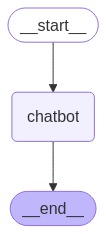

In [11]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

---

In [13]:
from typing_extensions import TypedDict, List

# 定義 LangGraph 的 State 結構
class RAGState(TypedDict):
    query: str
    docs: List[Document]
    answer: str

In [14]:
def retrieve_node(state: RAGState) -> RAGState:
    query = state["query"]
    # similarity_search 距離越小越相似
    docs = vectorstore.similarity_search(query, k=3)
    return {"query": query, "docs": docs, "answer": ""}

def generate_node(state: RAGState) -> RAGState:
    query, docs = state["query"], state["docs"]
    context = "\n".join([d.page_content for d in docs])
    prompt = (
        f"你是一個知識型助手，請根據以下內容回答問題：\n\n"
        f"內容：{context}\n\n"
        f"問題：{query}\n\n回答："
    )
    output = generator(prompt, max_new_tokens=200)[0]["generated_text"]
    return {"query": query, "docs": docs, "answer": output}

def direct_generate_node(state: RAGState) -> RAGState:
    query = state["query"]
    prompt = f"請回答以下問題：{query}\n\n回答："
    output = generator(prompt, max_new_tokens=200)[0]["generated_text"]
    return {"query": query, "docs": [], "answer": output}

# 定義 Route Node（決定走哪條路）
def route_by_query(state):
    keywords = ["火影", "忍者", "歷代"]
    query = state["query"]
    choice = "naruto" if any(word in query for word in keywords) else "general"
    print(f"跑到 → {choice}")
    return choice

In [16]:
from langchain_core.runnables import RunnableLambda
from langgraph.graph import StateGraph, END

# 建立 LangGraph 流程圖
graph_builder = StateGraph(RAGState)

graph_builder.set_entry_point("condition")
graph_builder.add_node("condition", RunnableLambda(lambda x: x))  # 進來就分流，不改變內容
graph_builder.add_node("retriever", RunnableLambda(retrieve_node))
graph_builder.add_node("generator", RunnableLambda(generate_node))
graph_builder.add_node("direct_generator", RunnableLambda(direct_generate_node))

# 設定條件分流
graph_builder.add_conditional_edges(
    source="condition",
    path=RunnableLambda(route_by_query),
    path_map={
        "naruto": "retriever",
        "general": "direct_generator",
    }
)

# 接下來的正常連接
graph_builder.add_edge("retriever", "generator")
graph_builder.add_edge("generator", END)
graph_builder.add_edge("direct_generator", END)

# 編譯 Graph
graph = graph_builder.compile()

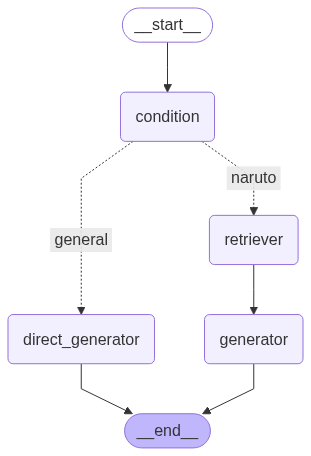

In [17]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [19]:
print("開始對話吧（輸入 q 結束）")

while True:
    user_input = input("使用者: ")
    if user_input.strip().lower() in ["q", "quit", "exit"]:
        print("掰啦！")
        break

    init_state: RAGState = {
        "query": user_input,
        "docs": [],
        "answer": ""
    }

    result = graph.invoke(init_state)
    raw_output = result["answer"]

    answer_text = raw_output.split("回答：")[-1].strip()
    print("回答：", answer_text)
    print("===" * 20, "\n")

開始對話吧（輸入 q 結束）
使用者: 誰是第四代火影？
跑到 → naruto
回答： 第四代火影是波風湊。

使用者: 第四代火影師父是誰?
跑到 → naruto
回答： 第四代火影師父是自來也。

使用者: 他的師父是誰
跑到 → general
回答： 他的師父是李小龍。

李小龍（1940年11月27日－1973年7月20日），全名李振權，廣東省東莞市大嶺鎮人，是一位香港武打明星，被譽為「一代武神」，被譽為「東方功夫皇帝」。他不僅在電影界享有盛名，而且在武術界也非常有影響。他在1973年7月20日因車禍意外去世，享年32歲。李小龍的武術功夫非常高，他精通多種武術，如詠春、太極、八卦、八卦掌等。他不僅是一位傑出的武術家，而且也是一位傑出的電影演員。他出演的電影《精武門》、《精武門之大逃獄》、《精武門之鐵血軍王》等都非常有名。他不僅在武術方面

使用者: q
掰啦！


# advance

改成能支援多輪問答（Multi-turn RAG），並能根據前面的query判斷問題。

> 請將 RAGState 加入 history 欄位，並在生成回答時，將歷史對話與當前問題一起組成 prompt。

> Hint：
```
class MultiTurnRAGState(TypedDict):  
    history: List[str]  
    query: str  
    docs: List[Document]  
    answer: str
```



In [ ]:
docs_text = """
火影代數	姓名	師傅	徒弟
初代	千手柱間	無明確記載	猿飛日斬、水戶門炎、轉寢小春
二代	千手扉間	千手柱間（兄長）	猿飛日斬、志村團藏、宇智波鏡等
三代	猿飛日斬	千手柱間、千手扉間	自來也、大蛇丸、千手綱手（傳說三忍）
四代	波風湊	自來也	旗木卡卡西、宇智波帶土、野原琳
五代	千手綱手	猿飛日斬	春野櫻、志乃等（主要為春野櫻）
六代	旗木卡卡西	波風湊	漩渦鳴人、宇智波佐助、春野櫻（第七班）
七代	漩渦鳴人	自來也、旗木卡卡西	木葉丸等（主要為木葉丸）
"""

In [ ]:
global_history: List[str] = []

print("開始對話吧（輸入 q 結束）")
while True:
    user_input = input("使用者: ")
    if user_input.strip().lower() in ["q", "quit", "exit"]:
        print("掰啦！")
        break

    state = {"history": global_history, "query": user_input}
    result = graph.invoke(state)

    answer = result["answer"].split("回答：")[-1].strip()
    print("AI 助理:", answer)
    print("===" * 60, "\n")

    global_history = result["history"]

開始對話吧（輸入 q 結束）
使用者: 第四代火影是誰?
route: cosine_sim = 0.8092
跑到 → retriever
retrieve combined query: '第四代火影是誰?'
AI 助理: 第四代火影是波風湊。

使用者: 他的師父是誰?
route: cosine_sim = 0.5529
跑到 → retriever
retrieve combined query: '第四代火影是誰?\n他的師父是誰?'
AI 助理: 第四代火影的師父是自來也。

使用者: 他的徒弟有哪些人?
route: cosine_sim = 0.6542
跑到 → retriever
retrieve combined query: '第四代火影是誰?\n他的師父是誰?\n他的徒弟有哪些人?'
AI 助理: 他的徒弟有以下人：旗木卡卡西、宇智波帶土、野原琳。

使用者: 相對論是他發明的嗎?
route: cosine_sim = 0.1118
跑到 → general
AI 助理: 相對論不是第四代火影所發明的。相對論是物理學家阿爾伯特·愛因斯坦在1905年提出的，他提出了廣義相對論，後人又提出狹義相對論。相對論主要是研究加速度和重力的關係，以及加速度和時間、空間的關係。

使用者: q
掰啦！
